# Deep Learning Intro: Two Moons (PyTorch + NumPy)

This notebook is a hands-on introduction to deep learning using the classic **two-moons** dataset.

We will:

1. Generate a **large-scale** two-moons dataset.
2. Visualize the dataset.
3. Train a small **neural network (MLP)** in **PyTorch**.
4. Visualize the **decision boundary**.
5. Implement a simple **NumPy** neural net (manual backprop) to show how pytorch can abstract away the complexities.

> **Device note:** This notebook automatically uses the best available device:  
    - **Apple Silicon:** uses `mps` (Metal) if available  
    - **NVIDIA GPU:** uses `cuda` if available  
    - otherwise falls back to `cpu`


In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    '''
    Selects the best device (GPU) based on host system config.
    '''
    if torch.cuda.is_available():
        return torch.device("cuda")
    # Apple Silicon (Metal Performance Shaders)
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
device


device(type='mps')

In [2]:
# -----------------------------
# 1) Generate a large two-moons dataset
# -----------------------------
n_samples = 20_000
noise = 0.20

X, y = make_moons(n_samples=n_samples, noise=noise, random_state=SEED)
X = X.astype(np.float32)
y = y.astype(np.int64)

# Standardize features (important for MLPs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train.shape, X_test.shape


((16000, 2), (4000, 2))

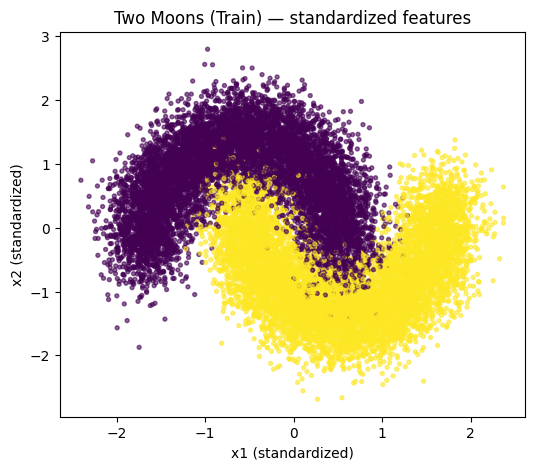

In [3]:
# -----------------------------
# 2) Visualize the dataset
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=8, alpha=0.6)
plt.title("Two Moons (Train) — standardized features")
plt.xlabel("x1 (standardized)")
plt.ylabel("x2 (standardized)")
plt.show()

## PyTorch MLP Classifier

We'll train a small **MLP** (fully connected network) to classify the two moons.

Throughout this notebook, you may place `print()` statements and early exists using `sys.exit()` to examine the objects (especially their shape) as they pass through the network. Note the commented out statements in the `accuracy` function definition.


In [4]:
# -----------------------------
# 3) PyTorch model + training loop
# -----------------------------
batch_size = 512

# We convert the data to TensorDataset type. We can use numpy, but using TensorDataset
# removes potential compatibility friction and also is required if using DataLoader (below)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

# We feed our numpy dataset into DataLoader which makes things like batch-training much easier.
# Without that, we have to feed the data batch by batch in our training loop.
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# The Sequential class from pytorch makes it easier to layer in different modules
# You can add Linear and ReLU (or other non-linearity) in whatever pattern you like.
# As long as you pay attention to basic neural net design principles.
# This is also where you can add normalization and regularization (like dropout)
model = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 2),
)

# We send the model to our device (GPU).
# Notice that we generated the device object using our helper fuction in the first
# code-block of the notebook.
model = model.to(device)

# We pick a loss (criterion) as well as an optimizer and instantiate them.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def accuracy(model, loader):
    '''
    Takes a trained model and data loader object and computes the accuracy score.
    '''
    model.eval() # Puts the model in evaluation mode which disables gradient computations.
    correct = 0
    total = 0
    # torch.no_grad() is another way to disable gradient computation.
    with torch.no_grad():
        for xb, yb in loader:
            # We send dataset to device just like we did with the model.
            xb = xb.to(device)
            # print(xb.shape)
            yb = yb.to(device)
            # print(yb.shape)
            logits = model(xb)
            # print(logits)
            pred = logits.argmax(dim=1)
            # print(pred)
            # sys.exit()
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / total

# Train
n_epochs = 25
train_acc_hist = []
test_acc_hist = []

# This is our main training loop.
for epoch in range(1, n_epochs + 1):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    tr_acc = accuracy(model, train_loader)
    te_acc = accuracy(model, test_loader)
    # We collect each computed accuracy store in our hist(history) object
    # we initialized these objects above.
    train_acc_hist.append(tr_acc)
    test_acc_hist.append(te_acc)

    # Conditional printing to print the metrics on only specific iterations.
    if epoch in {1, 2, 3, 5, 10, 15, 20, 25}:
        print(f"Epoch {epoch:>2d}/{n_epochs} | train acc={tr_acc:.4f} | test acc={te_acc:.4f}")


Epoch  1/25 | train acc=0.8685 | test acc=0.8630
Epoch  2/25 | train acc=0.8952 | test acc=0.8922
Epoch  3/25 | train acc=0.9207 | test acc=0.9203
Epoch  5/25 | train acc=0.9640 | test acc=0.9665
Epoch 10/25 | train acc=0.9704 | test acc=0.9712
Epoch 15/25 | train acc=0.9706 | test acc=0.9718
Epoch 20/25 | train acc=0.9704 | test acc=0.9712
Epoch 25/25 | train acc=0.9705 | test acc=0.9718


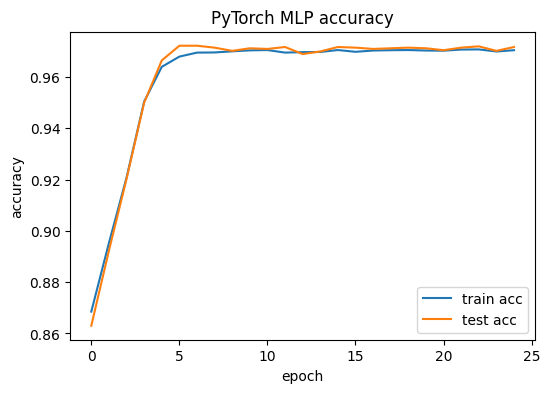

In [5]:
# Accuracy curves
plt.figure(figsize=(6, 4))
plt.plot(train_acc_hist, label="train acc")
plt.plot(test_acc_hist, label="test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("PyTorch MLP accuracy")
plt.legend()
plt.show()

## Decision Boundary (PyTorch)

We evaluate the model on a dense grid and color regions by predicted class.

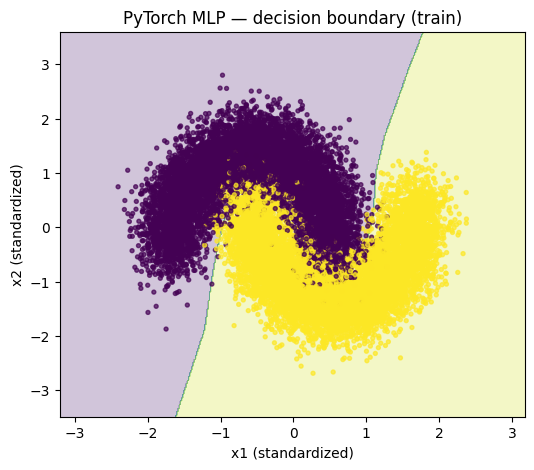

In [6]:
def plot_decision_boundary_pytorch(model, X, y, title="Decision boundary", grid_size=400):
    model.eval()
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    with torch.no_grad():
        logits = model(torch.from_numpy(grid).to(device))
        preds = logits.argmax(dim=1).cpu().numpy()

    Z = preds.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=8, alpha=0.7)
    plt.title(title)
    plt.xlabel("x1 (standardized)")
    plt.ylabel("x2 (standardized)")
    plt.show()

plot_decision_boundary_pytorch(model, X_train, y_train, title="PyTorch MLP — decision boundary (train)")


## NumPy Neural Net (Manual Backprop)

Now we implement a tiny 2-layer MLP *from scratch* using NumPy.

Goals:
- Show the same idea (forward pass → loss → gradients → update)
- Illustrate the benefits of frameworks like PyTorch:
    - Convenience.
    - More stable computation (prevention of division by zero etc.)
    - Much faster computation.


Epoch  1/100 | loss=0.3182 | acc=0.8690
Epoch  2/100 | loss=0.2942 | acc=0.8712
Epoch  3/100 | loss=0.2874 | acc=0.8732
Epoch  5/100 | loss=0.2825 | acc=0.8750
Epoch 10/100 | loss=0.2781 | acc=0.8772
Epoch 15/100 | loss=0.2750 | acc=0.8792
Epoch 20/100 | loss=0.2720 | acc=0.8822
Epoch 25/100 | loss=0.2691 | acc=0.8832


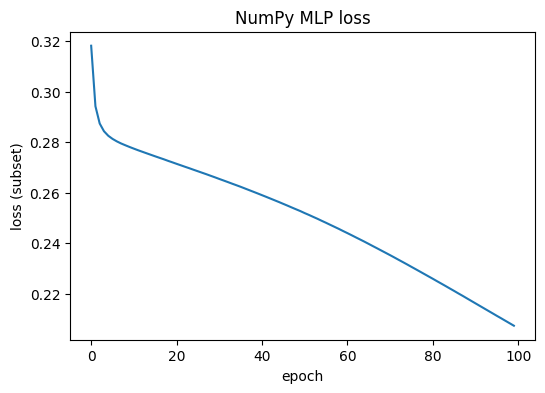

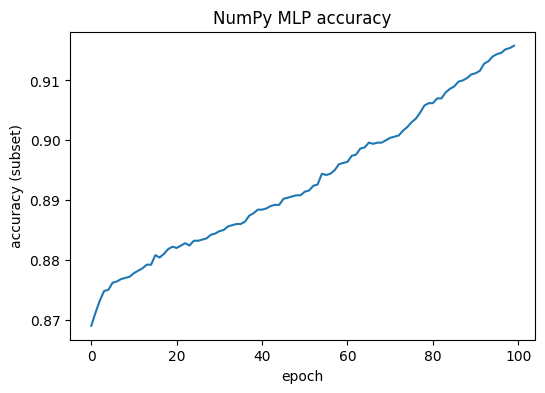

In [7]:
# -----------------------------
# 4) NumPy implementation (2-layer MLP)
# -----------------------------

def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(z.dtype)

def softmax(logits):
    # stable softmax
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)

def cross_entropy(probs, y):
    # y: int labels
    n = y.shape[0]
    # small epsilon for safety
    eps = 1e-12
    return -np.mean(np.log(probs[np.arange(n), y] + eps))

def accuracy_numpy(probs, y):
    return (probs.argmax(axis=1) == y).mean()

# Data for NumPy training
Xn = X_train.astype(np.float32)
yn = y_train.astype(np.int64)

n, d = Xn.shape
h = 64
k = 2

rng = np.random.default_rng(SEED)

# He init for ReLU
W1 = (rng.standard_normal((d, h)).astype(np.float32) * np.sqrt(2.0/d))
b1 = np.zeros((1, h), dtype=np.float32)
W2 = (rng.standard_normal((h, k)).astype(np.float32) * np.sqrt(2.0/h))
b2 = np.zeros((1, k), dtype=np.float32)

lr = 1e-2
batch_size = 512
epochs = 100

# Training loop
loss_hist = []
acc_hist = []

for epoch in range(1, epochs + 1):
    # shuffle
    idx = rng.permutation(n)
    Xs = Xn[idx]
    ys = yn[idx]

    for start in range(0, n, batch_size):
        xb = Xs[start:start+batch_size]
        yb = ys[start:start+batch_size]
        m = xb.shape[0]

        # Forward
        z1 = xb @ W1 + b1      # (m, h)
        a1 = relu(z1)          # (m, h)
        z2 = a1 @ W2 + b2      # (m, k)
        probs = softmax(z2)    # (m, k)

        # Loss gradient w.r.t logits (softmax + CE simplifies)
        dz2 = probs
        dz2[np.arange(m), yb] -= 1.0
        dz2 /= m               # (m, k)

        # Backprop
        dW2 = a1.T @ dz2       # (h, k)
        db2 = dz2.sum(axis=0, keepdims=True)

        da1 = dz2 @ W2.T       # (m, h)
        dz1 = da1 * relu_grad(z1)

        dW1 = xb.T @ dz1       # (d, h)
        db1 = dz1.sum(axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    # Epoch metrics on a subset (to keep it quick)
    # (You can evaluate on full data if desired.)
    eval_idx = slice(0, min(5000, n))
    z1 = Xn[eval_idx] @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    probs = softmax(z2)

    loss = cross_entropy(probs, yn[eval_idx])
    acc = accuracy_numpy(probs, yn[eval_idx])

    loss_hist.append(loss)
    acc_hist.append(acc)

    if epoch in {1, 2, 3, 5, 10, 15, 20, 25}:
        print(f"Epoch {epoch:>2d}/{epochs} | loss={loss:.4f} | acc={acc:.4f}")


plt.figure(figsize=(6, 4))
plt.plot(loss_hist)
plt.xlabel("epoch")
plt.ylabel("loss (subset)")
plt.title("NumPy MLP loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(acc_hist)
plt.xlabel("epoch")
plt.ylabel("accuracy (subset)")
plt.title("NumPy MLP accuracy")
plt.show()


## Notes / Tips

- If you want training to be faster on CPU, try reducing `n_samples` or increasing `batch_size`.
- If you're on Apple Silicon, PyTorch will use `mps` if installed with MPS support.
- If you're on Linux with NVIDIA, you’ll get `cuda` automatically if your PyTorch build supports it.

### Optional extensions (good after-class exercises)
- Add **weight decay** (L2 regularization) to PyTorch (`AdamW`).
- Try different activations (tanh vs ReLU).
- Increase depth (more hidden layers) and observe overfitting.
- Compare against **LogisticRegression** baseline from sklearn.


## Extra Exercise

In the following block we train a model that uses a popular dataset (MNIST) and predicts the handwritten digits.

- Note that here we're using some of the more advanced object-orientation programming concepts in python such as class definition for MLP object.
- Follow along the code, examine the training and evaluation loop.
- Notice how we are treating the image data (flattening the matrix and converting to a vector).
- Try adding/removing components to the network (e.g. regularization or standardization). This network is defined inside our MLP class.
- Try pulling out and visualizing the images that are being misclassified. What is the issue with these images?

Epoch 1: Loss=0.2688, Accuracy=0.9216
Epoch 2: Loss=0.1056, Accuracy=0.9673
Epoch 3: Loss=0.0724, Accuracy=0.9772
Epoch 4: Loss=0.0530, Accuracy=0.9838
Epoch 5: Loss=0.0427, Accuracy=0.9859
Test Accuracy: 0.9786


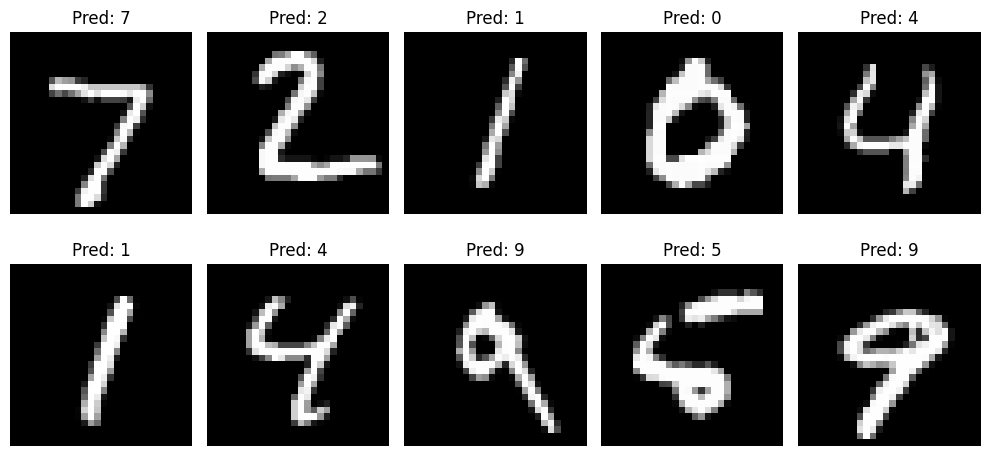

In [8]:
# ============================================
# Handwritten Digits (MNIST) with PyTorch
# ============================================
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# -----------------------------
# Load MNIST
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# -----------------------------
# Simple MLP Model
# -----------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# Training Loop
# -----------------------------
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    print(f"Epoch {epoch+1}: "
          f"Loss={total_loss/len(train_loader):.4f}, "
          f"Accuracy={correct/total:.4f}")

# -----------------------------
# Evaluate on Test Set
# -----------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print("Test Accuracy:", correct / total)

# -----------------------------
# Visualize Predictions
# -----------------------------
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1)

images = images.cpu().numpy()
preds = preds.cpu().numpy()
labels = labels.numpy()

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title(f"Pred: {preds[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()